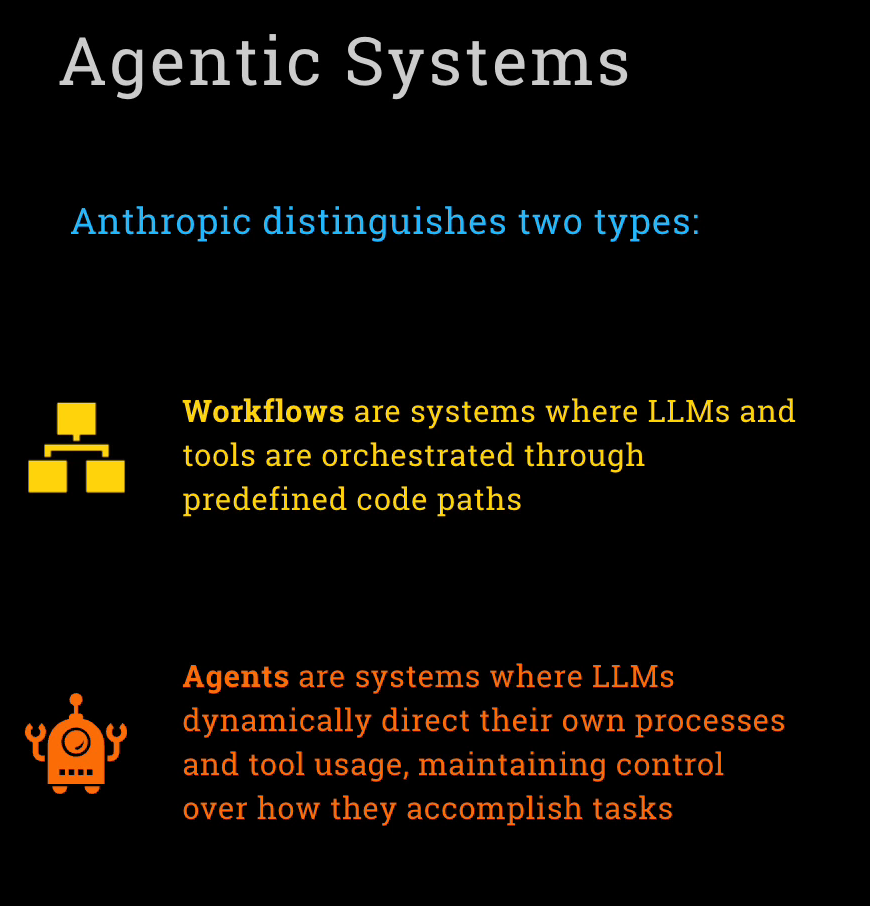

An **agent** is something that **perceives, decides, and acts** toward a goal.

In simple terms, an agent is “on”:

* **an environment**: the world or system it interacts with
* **a state**: what it currently knows or observes
* **a goal**: what it is trying to achieve
* **actions/tools**: what it can do next
* **feedback**: the result of its action

So the core idea is:

**observe → reason/choose → act → learn from result**

### Where the ambiguity comes in

The word **agent** is used in different ways:

1. **Classical AI agent**
   A program that takes inputs from an environment and chooses actions.

2. **LLM agent**
   A language model that can call tools, plan steps, and act over multiple turns.

3. **Autonomous agent**
   Something that keeps working with minimal human input.

4. **Human agent**
   A person acting on behalf of someone else.

### What people argue about

The ambiguity is usually about these questions:

* Does it need **memory** to be called an agent?
* Does it need **tools**?
* Does it need to **plan**?
* Does it need to act **autonomously**?
* Is a chatbot an agent, or only a tool?
* Is an agent the **model**, the **workflow**, or the **whole system**?

### A clean way to think about it

An agent is not just “a model that answers.”
It is a system that can:

* understand context,
* choose a next step,
* use tools if needed,
* and move toward a goal.

### Example

If you ask:

“Book me a train ticket.”

A normal model may only suggest steps.
An agent may:

* check availability,
* compare options,
* fill details,
* ask for confirmation,
* and complete the booking.

That is why “agent” usually means **action-oriented AI**, not just text generation.

I can also break this down into **AI agent vs chatbot vs automation vs autonomous system** in a very simple comparison.


There is no single universal standard, but in current agent-building practice the most common workflow design patterns are the ones Anthropic and LangGraph describe: **prompt chaining, routing, parallelization, orchestrator-worker, evaluator-optimizer, and agent loops**, with **multi-agent systems** and **human-in-the-loop controls** as important extensions. Anthropic explicitly frames these as common building blocks, and LangGraph models them as graphs made from state, nodes, and edges. ([Anthropic][1])

The main patterns are:

**1) Prompt chaining** — split one job into fixed steps, where each step feeds the next. This is useful when the task can be cleanly decomposed and you want more accuracy by making each step simpler. ([Anthropic][1])

**2) Routing** — classify the input first, then send it to the right specialized path, prompt, model, or tool. This is useful when different kinds of requests need different handling. ([Anthropic][1])

**3) Parallelization** — run independent sub-tasks at the same time, then merge the results. Anthropic describes two common forms here: **sectioning** and **voting**. ([Anthropic][1])

**4) Orchestrator-worker** — a central agent breaks the work into parts, delegates to workers, and then synthesizes the results. This is especially useful when the subtasks are not known in advance. ([Anthropic][1])

**5) Evaluator-optimizer** — one model generates, another critiques or scores, and the system loops until the result is good enough. This is a strong pattern for writing, translation, analysis, and other tasks where iteration improves quality. ([Anthropic][1])

**6) Agent loop / ReAct-style loop** — the model repeatedly thinks, takes an action, observes the result, and decides the next move. Hugging Face describes agent work as a Thought-Action-Observation cycle, and OpenAI describes agents as systems that use models, tools, state/memory, and orchestration. ([Hugging Face][2])

**7) Multi-agent systems** — several specialized agents cooperate on a task. Hugging Face and Anthropic both describe this as useful when tasks are broad, parallelizable, or too large for one context window. Anthropic’s 2025 research write-up specifically uses an orchestrator-worker multi-agent design. ([Hugging Face][3])

**8) Human-in-the-loop workflows** — pause the system for approval, editing, or rejection before risky actions. LangGraph supports this with interrupts and human-in-the-loop middleware. ([LangChain Docs][4])

At the implementation level, modern systems often use a **graph-based workflow** with **sequences, branches, loops, conditional edges, subgraphs, and checkpoints**. LangGraph is built around exactly this idea: state + nodes + edges, where edges decide what happens next. ([LangChain Docs][5])

A practical way to think about it is:

* **Workflow patterns** = fixed control flow, branching, loops, and handoffs.
* **Agent patterns** = the model decides the next action dynamically.
* **Agent system** = the full setup: workflow + agents + tools + memory + oversight. ([LangChain Docs][6])

OpenAI also recommends starting simple: begin with a **single agent** and only move to **multi-agent orchestration** when the task truly needs it. That matches the current engineering trend: use the least complex pattern that solves the problem reliably. ([cdn.openai.com][7])




The main risks are these:

**Prompt injection.** If an agent reads untrusted text from a webpage, email, file, or chat, hidden instructions can manipulate its behavior and push it toward unauthorized access or harmful actions. OWASP lists prompt injection as a top risk, and Anthropic says there is no single defense that guarantees safety against it. 

**Excessive autonomy.** Agent frameworks often give the model permission to act with less human oversight, which increases the chance of unintended consequences. OWASP explicitly calls this “excessive agency,” and Anthropic says agents can misread user intent and take actions the user did not mean. 

**Sensitive data leakage.** Agents often connect to email, files, calendars, internal docs, and APIs, so a mistake can expose private or proprietary data. OWASP highlights sensitive information disclosure and system prompt leakage as major risks, and Anthropic notes that the more tools and environment access an agent has, the more can be exposed if something goes wrong. 

**Unsafe tool/output handling.** If the framework does not validate model output before execution, a malformed or malicious output can lead to code execution or other downstream exploits. OWASP calls this insecure output handling, and OpenAI’s guidance separates the harness from the sandbox specifically so sensitive control-plane work stays protected. 

**Cost blowups and loops.** Agents can keep thinking, retrying, searching, or calling tools, which can create unbounded consumption, higher latency, and service disruption. OWASP includes model denial of service and unbounded consumption in its risk lists. 

**Brittleness and debugging difficulty.** Agent workflows are multi-step and stateful, so failures can come from the prompt, the tool, the environment, the memory, or the orchestration layer. OpenAI notes that agent workflows get brittle when they need a workspace but only get prompt context, and LangGraph explicitly warns that asynchronous checkpointing can miss a write if a process crashes mid-run. 

**Governance and accountability problems.** Once an agent can plan and act on its own, it becomes harder to answer who approved what, why it acted, and how to prove compliance. OpenAI’s governance guide and Anthropic’s trustworthy-agents framework both stress human control, permissions, transparency, and privacy as core requirements. 

So the practical takeaway is: **agent frameworks are not dangerous because they are agent frameworks; they are risky because they increase autonomy, tool access, and side effects.** The safer designs keep permissions narrow, require approval for sensitive actions, sandbox execution, log every tool call, and limit how much the agent can do at once.